In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
import snowflake.connector
import pandas as pd

conn = snowflake.connector.connect(
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema=os.getenv("SNOWFLAKE_SCHEMA_ANALYTICS"),
    role=os.getenv("SNOWFLAKE_ROLE"),
)

query = """
SELECT *
FROM OBT_TRIPS
LIMIT 100000
"""

df = pd.read_sql(query, conn)

df.head()

/tmp/ipykernel_63010/3296212413.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,PICKUP_DATETIME,DROPOFF_DATETIME,PICKUP_DATE,PICKUP_HOUR,DROPOFF_DATE,DROPOFF_HOUR,DAY_OF_WEEK,MONTH,YEAR,PU_LOCATION_ID,...,AIRPORT_FEE,EHAIL_FEE,TOTAL_AMOUNT,TRIP_DURATION_MIN,AVG_SPEED_MPH,TIP_PCT,RUN_ID,INGESTED_AT_UTC,SOURCE_YEAR,SOURCE_MONTH
0,2015-01-12 10:07:47,2015-01-12 10:22:05,2015-01-12,10,2015-01-12,10,1,1,2015,50,...,None,None,29.74,14.30,39.44,0.00,run_full_backfill_yellow_2015_01,2026-04-02 06:00:43.876558,2015,1
1,2015-01-12 10:08:16,2015-01-12 10:18:18,2015-01-12,10,2015-01-12,10,1,1,2015,140,...,None,None,9.80,10.03,9.57,0.00,run_full_backfill_yellow_2015_01,2026-04-02 06:00:43.876558,2015,1
2,2015-01-12 10:01:03,2015-01-12 10:17:48,2015-01-12,10,2015-01-12,10,1,1,2015,236,...,None,None,14.50,16.75,6.45,19.13,run_full_backfill_yellow_2015_01,2026-04-02 06:00:43.876558,2015,1
3,2015-01-12 10:24:12,2015-01-12 10:33:11,2015-01-12,10,2015-01-12,10,1,1,2015,79,...,None,None,10.40,8.98,9.75,20.00,run_full_backfill_yellow_2015_01,2026-04-02 06:00:43.876558,2015,1
4,2015-01-12 10:38:50,2015-01-12 10:52:15,2015-01-12,10,2015-01-12,10,1,1,2015,186,...,None,None,12.20,13.42,5.77,20.00,run_full_backfill_yellow_2015_01,2026-04-02 06:00:43.876558,2015,1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   PICKUP_DATETIME        100000 non-null  datetime64[ns]
 1   DROPOFF_DATETIME       100000 non-null  datetime64[ns]
 2   PICKUP_DATE            100000 non-null  object        
 3   PICKUP_HOUR            100000 non-null  int64         
 4   DROPOFF_DATE           100000 non-null  object        
 5   DROPOFF_HOUR           100000 non-null  int64         
 6   DAY_OF_WEEK            100000 non-null  int64         
 7   MONTH                  100000 non-null  int64         
 8   YEAR                   100000 non-null  int64         
 9   PU_LOCATION_ID         100000 non-null  int64         
 10  PU_ZONE                98333 non-null   object        
 11  PU_BOROUGH             99965 non-null   object        
 12  DO_LOCATION_ID         100000 non-null  int64

,PICKUP_HOUR,DROPOFF_HOUR,DAY_OF_WEEK,MONTH,YEAR,PU_LOCATION_ID,DO_LOCATION_ID,VENDOR_ID,RATE_CODE_ID,PAYMENT_TYPE,...,MTA_TAX,TIP_AMOUNT,TOLLS_AMOUNT,IMPROVEMENT_SURCHARGE,TOTAL_AMOUNT,TRIP_DURATION_MIN,AVG_SPEED_MPH,TIP_PCT,SOURCE_YEAR,SOURCE_MONTH
count,100000.000000,100000.000000,100000.000000,100000.0,100000.0,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,99997.000000,99984.000000,100000.0,100000.0
mean,14.890870,15.024640,1.605680,1.0,2015.0,166.215410,164.309710,1.52127,1.026500,1.365570,...,0.498820,1.606048,0.269289,0.299220,14.851248,16.054268,13.527197,13.532970,2015.0,1.0
std,5.204355,5.254945,0.488707,0.0,0.0,65.477375,69.484849,0.49955,0.377332,0.488765,...,0.024261,2.221390,1.320960,0.015277,12.254920,851.723813,201.256528,13.134789,0.0,0.0
min,0.000000,0.000000,1.000000,1.0,2015.0,1.000000,1.000000,1.00000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.300000,0.000000,0.000000,0.000000,2015.0,1.0
25%,11.000000,12.000000,1.000000,1.0,2015.0,132.000000,113.000000,1.00000,1.000000,1.000000,...,0.500000,0.000000,0.000000,0.300000,8.300000,6.370000,7.790000,0.000000,2015.0,1.0
50%,15.000000,16.000000,2.000000,1.0,2015.0,162.000000,162.000000,2.00000,1.000000,1.000000,...,0.500000,1.200000,0.000000,0.300000,11.300000,10.200000,10.320000,16.670000,2015.0,1.0
75%,19.000000,19.000000,2.000000,1.0,2015.0,234.000000,234.000000,2.00000,1.000000,2.000000,...,0.500000,2.150000,0.000000,0.300000,16.300000,16.120000,13.850000,22.310000,2015.0,1.0
max,23.000000,23.000000,2.000000,1.0,2015.0,265.000000,265.000000,2.00000,99.000000,4.000000,...,0.500000,100.000000,85.330000,0.300000,800.300000,269163.980000,54136.690000,784.620000,2015.0,1.0


Validaciones

In [4]:
df.isnull().sum().sort_values(ascending=False)

AIRPORT_FEE              100000
TRIP_TYPE                100000
EHAIL_FEE                100000
CONGESTION_SURCHARGE     100000
PU_ZONE                    1667
DO_ZONE                    1512
DO_BOROUGH                  176
PU_BOROUGH                   35
TIP_PCT                      16
AVG_SPEED_MPH                 3
IMPROVEMENT_SURCHARGE         0
FARE_AMOUNT                   0
EXTRA                         0
MTA_TAX                       0
TIP_AMOUNT                    0
TOLLS_AMOUNT                  0
PICKUP_DATETIME               0
TRIP_DISTANCE                 0
TOTAL_AMOUNT                  0
TRIP_DURATION_MIN             0
RUN_ID                        0
INGESTED_AT_UTC               0
SOURCE_YEAR                   0
STORE_AND_FWD_FLAG            0
PAYMENT_TYPE_DESC             0
PASSENGER_COUNT               0
DROPOFF_DATETIME              0
PICKUP_DATE                   0
PICKUP_HOUR                   0
DROPOFF_DATE                  0
DROPOFF_HOUR                  0
DAY_OF_W

In [5]:
df.duplicated().sum()

0

In [8]:
df.columns.tolist()

['PICKUP_DATETIME',
 'DROPOFF_DATETIME',
 'PICKUP_DATE',
 'PICKUP_HOUR',
 'DROPOFF_DATE',
 'DROPOFF_HOUR',
 'DAY_OF_WEEK',
 'MONTH',
 'YEAR',
 'PU_LOCATION_ID',
 'PU_ZONE',
 'PU_BOROUGH',
 'DO_LOCATION_ID',
 'DO_ZONE',
 'DO_BOROUGH',
 'SERVICE_TYPE',
 'VENDOR_ID',
 'VENDOR_NAME',
 'RATE_CODE_ID',
 'RATE_CODE_DESC',
 'PAYMENT_TYPE',
 'PAYMENT_TYPE_DESC',
 'TRIP_TYPE',
 'PASSENGER_COUNT',
 'TRIP_DISTANCE',
 'STORE_AND_FWD_FLAG',
 'FARE_AMOUNT',
 'EXTRA',
 'MTA_TAX',
 'TIP_AMOUNT',
 'TOLLS_AMOUNT',
 'IMPROVEMENT_SURCHARGE',
 'CONGESTION_SURCHARGE',
 'AIRPORT_FEE',
 'EHAIL_FEE',
 'TOTAL_AMOUNT',
 'TRIP_DURATION_MIN',
 'AVG_SPEED_MPH',
 'TIP_PCT',
 'RUN_ID',
 'INGESTED_AT_UTC',
 'SOURCE_YEAR',
 'SOURCE_MONTH']

In [9]:
df.columns = df.columns.str.lower()
df.columns.tolist()

['pickup_datetime',
 'dropoff_datetime',
 'pickup_date',
 'pickup_hour',
 'dropoff_date',
 'dropoff_hour',
 'day_of_week',
 'month',
 'year',
 'pu_location_id',
 'pu_zone',
 'pu_borough',
 'do_location_id',
 'do_zone',
 'do_borough',
 'service_type',
 'vendor_id',
 'vendor_name',
 'rate_code_id',
 'rate_code_desc',
 'payment_type',
 'payment_type_desc',
 'trip_type',
 'passenger_count',
 'trip_distance',
 'store_and_fwd_flag',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'congestion_surcharge',
 'airport_fee',
 'ehail_fee',
 'total_amount',
 'trip_duration_min',
 'avg_speed_mph',
 'tip_pct',
 'run_id',
 'ingested_at_utc',
 'source_year',
 'source_month']

In [10]:
df[df["trip_distance"] < 0]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


In [11]:
df[df["total_amount"] < 0]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


In [12]:
df[df["fare_amount"] < 0]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


In [13]:
df[df["trip_duration_min"] < 0]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


In [14]:
df[df["avg_speed_mph"] < 0]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


In [15]:
df[[
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "trip_duration_min",
    "avg_speed_mph",
    "tip_pct"
]].describe()

,trip_distance,fare_amount,tip_amount,total_amount,trip_duration_min,avg_speed_mph,tip_pct
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,99997.000000,99984.000000
mean,2.690442,11.780751,1.606048,14.851248,16.054268,13.527197,13.532970
std,3.364574,10.026149,2.221390,12.254920,851.723813,201.256528,13.134789
min,0.010000,0.000000,0.000000,0.300000,0.000000,0.000000,0.000000
25%,0.990000,6.500000,0.000000,8.300000,6.370000,7.790000,0.000000
50%,1.600000,9.000000,1.200000,11.300000,10.200000,10.320000,16.670000
75%,2.800000,13.000000,2.150000,16.300000,16.120000,13.850000,22.310000
max,99.900000,800.000000,100.000000,800.300000,269163.980000,54136.690000,784.620000


In [16]:
df[df["dropoff_datetime"] < df["pickup_datetime"]]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


In [17]:
df["service_type"].value_counts()

yellow    100000
Name: service_type, dtype: int64

In [18]:
df.groupby(["source_year", "source_month", "service_type"]).size().reset_index(name="total_rows")

,source_year,source_month,service_type,total_rows
0,2015,1,yellow,100000


Exploracion

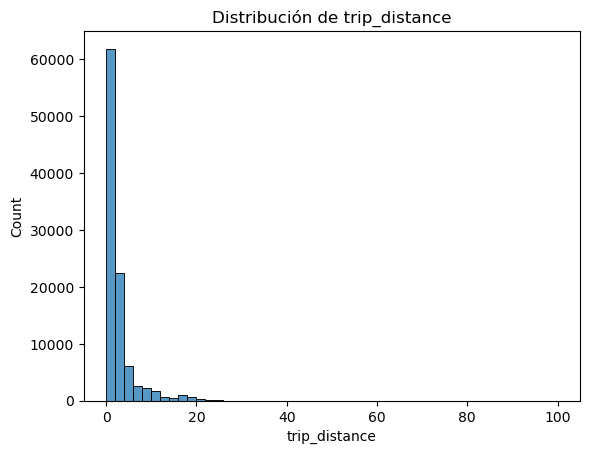

In [32]:
sns.histplot(df["trip_distance"], bins=50)
plt.title("Distribución de trip_distance")
plt.show()

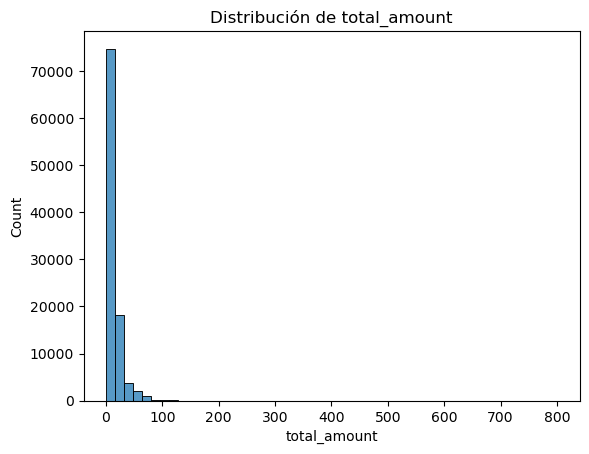

In [33]:
sns.histplot(df["total_amount"], bins=50)
plt.title("Distribución de total_amount")
plt.show()

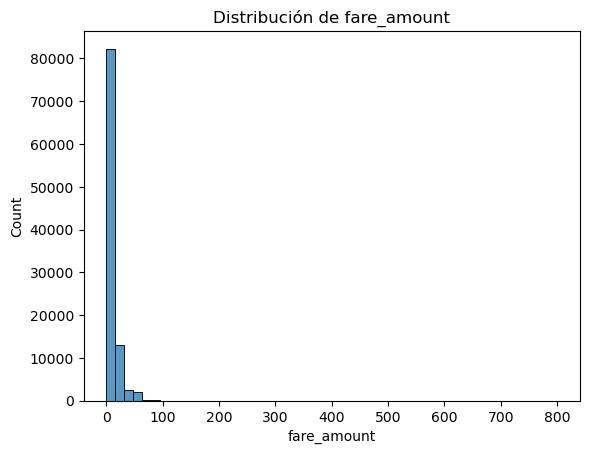

In [34]:
sns.histplot(df["fare_amount"], bins=50)
plt.title("Distribución de fare_amount")
plt.show()

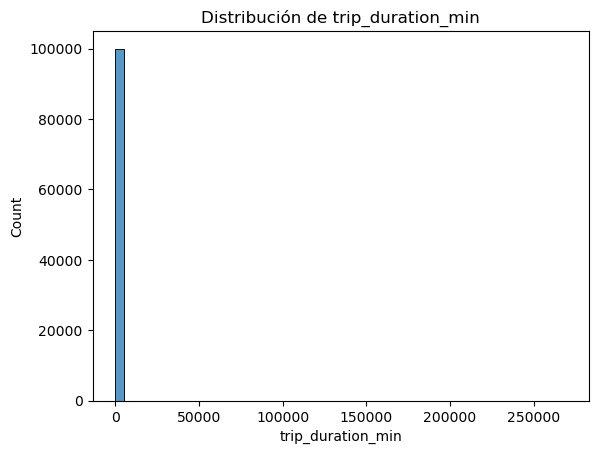

In [35]:
sns.histplot(df["trip_duration_min"], bins=50)
plt.title("Distribución de trip_duration_min")
plt.show()

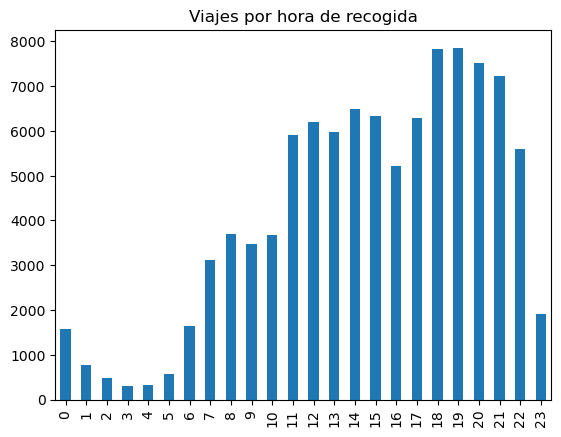

In [36]:
df["pickup_hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Viajes por hora de recogida")
plt.show()

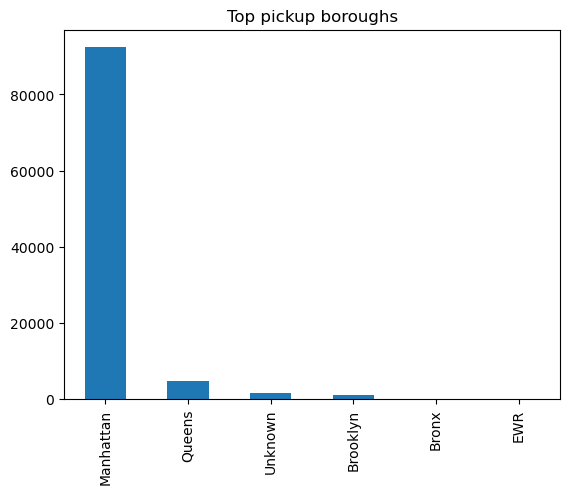

In [37]:
df["pu_borough"].value_counts().head(10).plot(kind="bar")
plt.title("Top pickup boroughs")
plt.show()

In [38]:
df.groupby("service_type")["total_amount"].mean().sort_values(ascending=False)

service_type
yellow    14.851248
Name: total_amount, dtype: float64

In [39]:
df.groupby("service_type")["trip_distance"].mean().sort_values(ascending=False)

service_type
yellow    2.690442
Name: trip_distance, dtype: float64

In [40]:
df.groupby("payment_type_desc")["tip_pct"].mean().sort_values(ascending=False)

payment_type_desc
Credit card    21.228870
Cash            0.000444
Dispute         0.000000
No charge       0.000000
Name: tip_pct, dtype: float64

In [41]:
df.groupby("pu_borough")["avg_speed_mph"].mean().sort_values(ascending=False)

pu_borough
EWR          779.950000
Queens        39.782341
Unknown       28.298926
Bronx         17.218684
Brooklyn      16.261936
Manhattan     11.777277
Name: avg_speed_mph, dtype: float64

In [42]:
conn.close()
print("Snowflake connection closed")

Snowflake connection closed
